In [1]:
import pandas as pd
url = "bank.csv" 
data = pd.read_csv(url, sep=";")
print(data.head())
print(data.columns.tolist())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failure  no  
3   unknown    3   jun       199         4     -1         0  unknown  no  
4   unknown    5   may       226         1     -1         0  unknown  no  
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'dur

In [4]:
X = data.drop("y", axis=1)
y = data["y"]
print(X.head())

   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  
0  cellular   19   oct        79         1     -1         0  unknown  
1  cellular   11   may       220         1    339         4  failure  
2  cellular   16   apr       185         1    330         1  failure  
3   unknown    3   jun       199         4     -1         0  unknown  
4   unknown    5   may       226         1     -1         0  unknown  


In [3]:
print(y.head())

0    no
1    no
2    no
3    no
4    no
Name: y, dtype: object


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # yes → 1, no → 0
print(y[:10])

[0 0 0 0 0 0 0 0 0 0]


In [6]:
X = pd.get_dummies(X, drop_first=True)
print(X.head())

   age  balance  day  duration  campaign  pdays  previous  job_blue-collar  \
0   30     1787   19        79         1     -1         0            False   
1   33     4789   11       220         1    339         4            False   
2   35     1350   16       185         1    330         1            False   
3   30     1476    3       199         4     -1         0            False   
4   59        0    5       226         1     -1         0             True   

   job_entrepreneur  job_housemaid  ...  month_jul  month_jun  month_mar  \
0             False          False  ...      False      False      False   
1             False          False  ...      False      False      False   
2             False          False  ...      False      False      False   
3             False          False  ...      False       True      False   
4             False          False  ...      False      False      False   

   month_may  month_nov  month_oct  month_sep  poutcome_other  \
0      Fa

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(criterion="entropy", max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9027624309392265


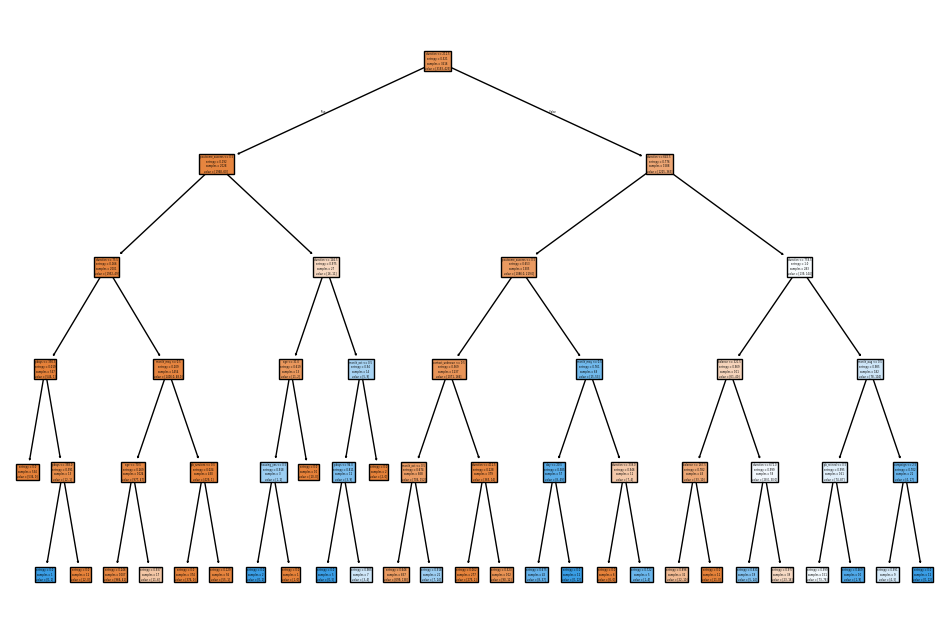

In [10]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(model, filled=True, feature_names=X.columns)
plt.show()